In [1]:
#Load required libraries
import pandas as pd

import tensorflow as tf
import keras
import numpy as np
import pickle

from keras.models import Sequential, Model
from keras.layers import Activation, Dense
from keras.layers import Conv2D, GlobalAveragePooling2D, BatchNormalization
from keras.layers import Dense, Dropout
from keras.layers import Dense, Dropout, Activation, Flatten
from keras import losses

In [2]:
with open(f'C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\simulacoes_com_erro.pkl', 'rb') as arquivo:
    simulacoes_com_erro = pickle.load(arquivo)

erros_validos = [i for i in simulacoes_com_erro if 0 <= i < 10000]

# loading parameters
param_train = pd.read_csv('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\tabela_100k_phyloCNN.txt', sep='\t')
#param_test = pd.read_csv('./testset/parameters_BD.txt', sep='\t')

param_train = param_train[:10000]
param_train = param_train.drop(erros_validos, axis=0)
param_test = param_train[-500:]
param_train = param_train[:-500]


n_de_mutantes = np.load('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\number_of_mutantes.npy')
n_de_mutantes = n_de_mutantes[:10000]
n_de_mutantes = np.delete(n_de_mutantes, erros_validos)
n_de_mutantes_test = n_de_mutantes[-500:]
n_de_mutantes_train = n_de_mutantes[:-500]


mask_train = n_de_mutantes_train <= 5
param_train.loc[mask_train, "R_nought_2"] = param_train.loc[mask_train, "R_nought_1"]

mask_test = n_de_mutantes_test <= 5
param_test.loc[mask_test, "R_nought_2"] = param_test.loc[mask_test, "R_nought_1"]

# loading tree encoding
#encoding = pd.read_csv('./Encoded_trees_BD.csv', sep="\t", header=0, index_col=0).values.reshape(-1,1000,18)
#encoding_test = pd.read_csv('./testset/Encoded_trees_BD.csv', sep="\t", header=0, index_col=0).values.reshape(-1,1000,18)

In [3]:
encoding = pd.read_csv('C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\mutation_dataset_100k_phyloCNN\\split_trees_encoded\\encoded_tree_part_0.csv', sep="\t", header=0, index_col=0).values.reshape(-1,1000,18)
print(encoding.shape)
encoding = np.delete(encoding, erros_validos, axis=0)
encoding_test = encoding[-500:]
encoding = encoding[:-500]

(10000, 1000, 18)


In [4]:
#Reshape parameters (and rescale them) and encodings:

### TRAINING SET: PARAMETER VALUES
# extract rescaling factor (last line of each encoded tree)
param_train['resc_factor'] = encoding[:,-1,-1]

# rescale target values according to scaling factor
# The BD and BDEI simulators use 'infectious time' for the name of this parameter. BDSS simulator use 'infectious period'.
key = 'infectious_period' if 'infectious_period' in param_train else 'infectious_time'
param_train['infectious_period'] = param_train.pop(key) / param_train['resc_factor']

### TESTING SET: PARAMETER VALUES
# extract rescaling factor  (last line of each encoded tree)
param_test['resc_factor'] = encoding_test[:,-1,-1]
# rescale target values
key = 'infectious_period' if 'infectious_period' in param_test else 'infectious_time'
param_test['infectious_period'] = param_test.pop(key) / param_test['resc_factor']

# remove irrelevant columns: rescaling factor
encoding=np.delete(encoding, -1, axis=1)
encoding_test=np.delete(encoding_test, -1, axis=1)

#Choice of the parameters to predict
target_1 = "R_nought_1"
target_2 = "R_nought_2"
target_3 = "infectious_period"

#Add parameters to predict as labels for each simulation
Y = pd.DataFrame(param_train[[target_1, target_2, target_3]])
Y_test = pd.DataFrame(param_test[[target_1, target_2, target_3]])

#Fraction of the training trees to be used as validation and training set
valid_frac = 0.3
train_size_frac = 0.7

In [5]:
#Now insert an additional column with sampling proba for all nodes

samp_proba_list = np.array(param_train['sampling_proba'])
encoding=np.concatenate((encoding,np.repeat(samp_proba_list,999).reshape(-1,999,1)),axis=2)

samp_proba_list_test = np.array(param_test['sampling_proba'])
encoding_test=np.concatenate((encoding_test,np.repeat(samp_proba_list_test,999).reshape(-1,999,1)),axis=2)

In [6]:
# This function takes in the tree encodings for both training and testing datasets
# and processes them to have a uniform shape. It also pads the leaves and nodes 
# of the trees to ensure each tree has a fixed number of 500 leaves and nodes.

def encode_pad_0s_rootage(enc, enc_test):
    # Create an empty list to hold padded training encodings
    enc_pad = []
    
    # Iterate over each tree in the training dataset
    for i in range(enc.shape[0]):
        # Separate the leaves (where column 3 has value 1, which indicates leaves)
        leaves = enc[i][enc[i,:,3] == 1]
        # Sort leaves by their age (assumed to be in column 1)
        leaves = leaves[np.argsort(leaves[:, 1])]
        # Pad the leaves array with 0s until it has a maximum size of 500 leaves
        leaves = np.pad(leaves, [(0, (500 - leaves.shape[0])), (0, 0)], mode='constant')

        # Separate the nodes (where column 3 is greater than 1, indicating internal nodes)
        nodes = enc[i][enc[i,:,3] > 1]
        # Sort nodes by their age (assumed to be in column 1)
        nodes = nodes[np.argsort(nodes[:, 1])]
        # Copy the last node's value to balance the number of leaves and nodes
        nodes = np.append(nodes, nodes[-1].reshape(1, -1), axis=0)
        # Pad the nodes array with 0s to ensure a size of 500 nodes
        nodes = np.pad(nodes, [(0, (500 - nodes.shape[0])), (0, 0)], mode='constant')
        
        # Stack the leaves and nodes arrays together along axis 2 (creating 2 channels)
        enc_pad.append(np.stack((leaves, nodes), axis=2))
    
    # Now process the test dataset (same procedure as above)
    enc_pad_test = []
    for i in range(enc_test.shape[0]):
        # Extract and sort leaves
        leaves = enc_test[i][enc_test[i,:,3] == 1]
        leaves = leaves[np.argsort(leaves[:, 1])]
        # Pad leaves to ensure size of 500
        leaves = np.pad(leaves, [(0, (500 - leaves.shape[0])), (0, 0)], mode='constant')

        # Extract and sort nodes
        nodes = enc_test[i][enc_test[i,:,3] > 1]
        nodes = nodes[np.argsort(nodes[:, 1])]
        # Copy the last node's value to balance the number of leaves and nodes
        nodes = np.append(nodes, nodes[-1].reshape(1, -1), axis=0)
        # Pad nodes to ensure size of 500
        nodes = np.pad(nodes, [(0, (500 - nodes.shape[0])), (0, 0)], mode='constant')
        
        # Stack the leaves and nodes arrays together along axis 2 (creating 2 channels)
        enc_pad_test.append(np.stack((leaves, nodes), axis=2))
    
    # Convert lists to numpy arrays and return the padded training and test data
    return np.array(enc_pad), np.array(enc_pad_test)


#Change encoding to order by root age and pad with 0s
encoding_pad, encoding_pad_test = encode_pad_0s_rootage(encoding, encoding_test)

In [10]:
# Creation of the Network Model: model definition
def build_model():
    # Initialize the Sequential model
    model = Sequential()
    
    # First convolutional layer: 
    # - Filters: 32 
    # - Kernel size: (1, 19), sliding across the second dimension of the input 
    # - Input shape: (500, 19, 2) where 500 is the number of tree leaves/nodes, 19 is the feature size, and 2 is the number of channels (leaves and nodes)
    # - Activation function: ELU (Exponential Linear Unit)
    # - Groups: 2 to apply separate convolutions for the two channels (leaves and nodes)
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 19), input_shape=(500, 19, 2), activation='elu', groups=2))
    
    # Apply batch normalization to stabilize and speed up the training process
    model.add(BatchNormalization())
    
    # Second convolutional layer: 
    # - Filters: 32
    # - Kernel size: (1, 1) to process each feature independently
    # - Activation function: ELU
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 1), activation='elu'))
    
    # Apply batch normalization again
    model.add(BatchNormalization())
    
    # Third convolutional layer: 
    # - Filters: 32
    # - Kernel size: (1, 1) for further feature processing
    # - Activation function: ELU
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 1), activation='elu'))
    
    # Apply batch normalization for the final time before flattening
    model.add(BatchNormalization())
    
    # Flatten the 2D feature maps from the convolutional layers into a 1D vector, 
    # which will be passed to the fully connected (dense) layers
    model.add(GlobalAveragePooling2D())
    
    # Fully connected (FFNN) part:
    # Dense layers with decreasing number of units, all using ELU activation:
    model.add(Dense(64, activation='elu'))   # First dense layer with 64 units
    model.add(Dense(32, activation='elu'))   # Second dense layer with 32 units
    model.add(Dense(16, activation='elu'))   # Third dense layer with 16 units
    model.add(Dense(8, activation='elu'))    # Fourth dense layer with 8 units
    
    # Output layer: 
    # - 2 output neurons, corresponding to the 2 target parameters to predict
    # - Activation function: ELU
    model.add(Dense(3, activation='linear')) # JPC changed 2 to 3 and the activation from elu to linear
    
    # Show the summary of the model structure (number of layers, shapes of outputs, etc.)
    model.summary()

    # Return the constructed model
    return model


In [ ]:


# Initialize the model using the build_model function that was previously defined
estimator = build_model()

# Compile the model:
# - Loss function: 'mean_absolute_percentage_error' (MAPE) is used to measure the error in terms of percentage for regression problems
# - Optimizer: 'Adam' is used to minimize the loss function efficiently
# - Metrics: 'mae' (mean absolute error) is used to track the model's performance during training
estimator.compile(loss=losses.mean_absolute_percentage_error, optimizer='Adam', metrics=['mae'])

# Early stopping callback to prevent overfitting:
# - monitor: monitor the validation loss during training
# - patience: stop training if the validation loss doesn't improve for 100 consecutive epochs
# - mode: 'min' indicates that training will stop when the validation loss reaches its minimum
# - restore_best_weights: restore the weights from the best epoch (the one with the lowest validation loss)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', restore_best_weights=True)

# Custom callback to display training progress:
# - Print a dot for every epoch (or newline every 100 epochs) to indicate progress in training
class PrintD(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0:  # Print a newline every 100 epochs
            print('')
        print('.', end='')  # Print a dot to indicate progress during each epoch

# Set the maximum number of epochs (iterations over the entire dataset)
EPOCHS = 1000

# Train the model using the `fit` method:
# - encoding_pad: The padded training data (inputs)
# - Y: The target values (outputs)
# - verbose: set to 1 to print progress during training
# - epochs: The number of times to iterate over the entire dataset
# - validation_split: the fraction of data to use for validation (used to monitor validation loss)
# - batch_size: the number of samples per gradient update
# - callbacks: list of callbacks to be used during training (early stopping and progress display)
history = estimator.fit(encoding_pad, Y, verbose=1, epochs=EPOCHS, validation_split=valid_frac, batch_size=1024, callbacks=[early_stop, PrintD()])



c:\Users\JPC\anaconda3\envs\phylodeepenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 500, 1, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500, 1, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 500, 1, 32)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 1, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 500, 1, 32)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 500, 1, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,923 (30.95 KB)

 Trainable params: 7,731 (30.20 KB)

 Non-trainable params: 192 (768.00 B)

In [7]:
path = 'C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\phyloCNN-main\\Trained_BDMT\\v0-corrected_mutation'

In [ ]:
# Save the model architecture to a JSON file:
# - The model structure (architecture) is saved as a JSON string


from keras.models import model_from_json
model = estimator.to_json()
with open(path + '\\Trained_BDMT_01-08_v0.json', 'w') as json_file:
    json_file.write(model)

# Save the model weights to an H5 file:
# - The weights (learned parameters) of the trained model are saved to a file
estimator.save_weights(path + '\\Trained_BDMT_01-08_v0.weights.h5')

# Print a confirmation message when the model and weights are saved
print('model saved!')

model saved!


In [10]:


estimator.save(path + "\\modeloJPC_01-08_v0.keras")

with open(path + "\\historyJPC_01-08_v0.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [8]:
#load the model
from keras.models import model_from_json
json_file = open(path + '\\Trained_BDMT_01-08_v0.json', 'r')
model = json_file.read()
json_file.close()
estimator = model_from_json(model)
#load weights
estimator.load_weights(path + '\\Trained_BDMT_01-08_v0.weights.h5')
print('model loaded!')



model loaded!


In [9]:
# predict values for the test set
predicted_test = pd.DataFrame(estimator.predict(encoding_pad_test))
predicted_test.columns = Y_test.columns # rename correctly the columns
predicted_test.index = Y_test.index # rename indexes for correspondence

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [ ]:

#Target
Y_test_rescaled=pd.DataFrame(Y_test)
Y_test_rescaled['infectious_period'] = Y_test_rescaled['infectious_period']*param_test['resc_factor']
#Y_test_rescaled.to_csv(path + '\\Y_test_rescaled.csv', header=True)

#Predicted
predicted_test['infectious_period'] = predicted_test['infectious_period']*param_test['resc_factor']
#predicted_test.to_csv(path + '\\predicted_test.csv', header=True)

In [22]:
predicted_test.head()

,R_nought_1,R_nought_2,infectious_period
9500,2.269968,2.306106,4.494697
9501,3.886568,10.308969,3.615533
9502,4.106964,4.299103,1.452033
9503,2.702710,6.531055,3.227719
9504,4.796465,13.018179,9.795442


In [12]:
mse_r01 = np.mean((Y_test_rescaled["R_nought_1"] - predicted_test["R_nought_1"])**2)
mse_r02 = np.mean((Y_test_rescaled["R_nought_2"] - predicted_test["R_nought_2"])**2)
mse_inf = np.mean((Y_test_rescaled["infectious_period"] - predicted_test["infectious_period"])**2)



print("MSE R01:", mse_r01)
print("MSE R02:", mse_r02)
print("MSE Inf:", mse_inf)

MSE R01: 0.16744021603485332
MSE R02: 1.9735426867390384
MSE Inf: 0.24744509681998103


In [13]:
mae_r01 = np.mean(np.abs(Y_test_rescaled["R_nought_1"] - predicted_test["R_nought_1"]))
mae_r02 = np.mean(np.abs(Y_test_rescaled["R_nought_2"] - predicted_test["R_nought_2"]))
mae_inf = np.mean(np.abs(Y_test_rescaled["infectious_period"] - predicted_test["infectious_period"]))

print("MAE R01:", mae_r01)
print("MAE R02:", mae_r02)
print("MAE Inf:", mae_inf)

MAE R01: 0.28303938845443727
MAE R02: 0.8665557788982392
MAE Inf: 0.33721742922009695


In [14]:
mape_r01 = np.mean(np.abs((Y_test_rescaled["R_nought_1"] - predicted_test["R_nought_1"]) / Y_test_rescaled["R_nought_1"]))
mape_r02 = np.mean(np.abs((Y_test_rescaled["R_nought_2"] - predicted_test["R_nought_2"]) / Y_test_rescaled["R_nought_2"]))
mape_inf = np.mean(np.abs((Y_test_rescaled["infectious_period"] - predicted_test["infectious_period"]) / Y_test_rescaled["infectious_period"]))

print("MAPE R01:", mape_r01)
print("MAPE R02:", mape_r02)
print("MAPE Inf:", mape_inf)


MAPE R01: 0.11053546300066026
MAPE R02: 0.13783919049879073
MAPE Inf: 0.06142700628518056


In [15]:
corr_r01 = np.corrcoef(Y_test_rescaled["R_nought_1"], predicted_test["R_nought_1"])[0,1]
corr_r02 = np.corrcoef(Y_test_rescaled["R_nought_2"], predicted_test["R_nought_2"])[0,1]
corr_inf = np.corrcoef(Y_test_rescaled["infectious_period"], predicted_test["infectious_period"])[0,1]
print("CORR R01:", corr_r01)
print("CORR R02:", corr_r02)
print("CORR Inf:", corr_inf)

CORR R01: 0.9352407851746335
CORR R02: 0.909383667226503
CORR Inf: 0.9822427699251434


In [16]:
print(f'''     & R01     & R02    & INF   \\\ \hline
MSE  & {mse_r01:.4f}  & {mse_r02:.4f} & {mse_inf:.4f} \\\ \hline
MAE  & {mae_r01:.4f} & {mae_r02:.4f} & {mae_inf:.4f} \\\ \hline
MAPE & {mape_r01:.4f}  & {mape_r02:.4f} & {mape_inf:.4f} \\\ \hline
CORR & {corr_r01:.4f}  & {corr_r02:.4f} & {corr_inf:.4f} \\\ \hline''')

     & R01     & R02    & INF   \\ \hline
MSE  & 0.1674  & 1.9735 & 0.2474 \\ \hline
MAE  & 0.2830 & 0.8666 & 0.3372 \\ \hline
MAPE & 0.1105  & 0.1378 & 0.0614 \\ \hline
CORR & 0.9352  & 0.9094 & 0.9822 \\ \hline


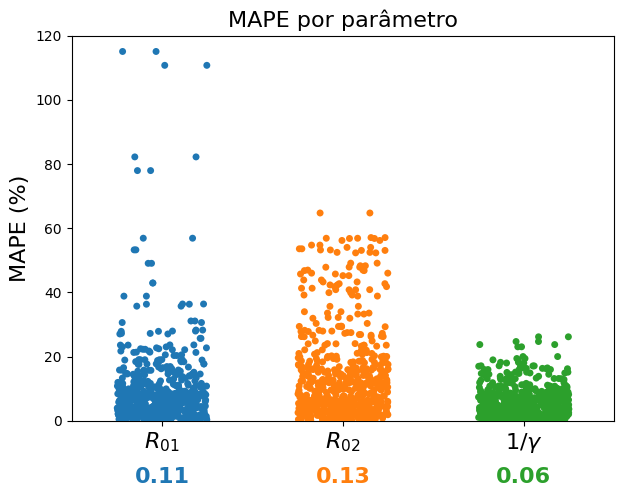

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# y_true and y_pred: shape (n_samples, 3)

mape = np.abs((Y_test_rescaled - predicted_test) / Y_test_rescaled) * 100
mape = mape[:300]
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(
    data=[mape['R_nought_1'], mape['R_nought_2'], mape['infectious_period']],
    jitter=0.25,
    size=5
)




sns.stripplot(
    data=mape,
    jitter=0.25,
    size=5,
    ax=ax
)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([r"$R_{01}$", r"$R_{02}$", r"$\frac{1}{\gamma}$" ], fontsize=16)

ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE distribution — first 100 observations")

# Numbers to display below each column
numbers = [0.11, f"{0.13:.2f}", 0.06]

# Get the colors used by the three columns
colors = sns.color_palette(n_colors=3)

for x, number, color in zip(range(3), numbers, colors):


    ax.text(
        x, -0.12,
        str(number),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        color=color,
        fontsize=16,
        fontweight="bold"
    )

plt.xticks([0, 1, 2], [r"$R_{01}$", r"$R_{02}$", r"$1/\gamma$"]  )
plt.ylabel("MAPE (%)", fontsize=16)
plt.title("MAPE por parâmetro", fontsize=16)
ax.set_ylim(0, 120)
plt.savefig("C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\jitter_plots\\mape_phylocnn.pdf", bbox_inches="tight")
plt.show()

In [26]:
print("Best epoch:", early_stop.best_epoch + 1)

AttributeError: 'EarlyStopping' object has no attribute 'best_epoch'

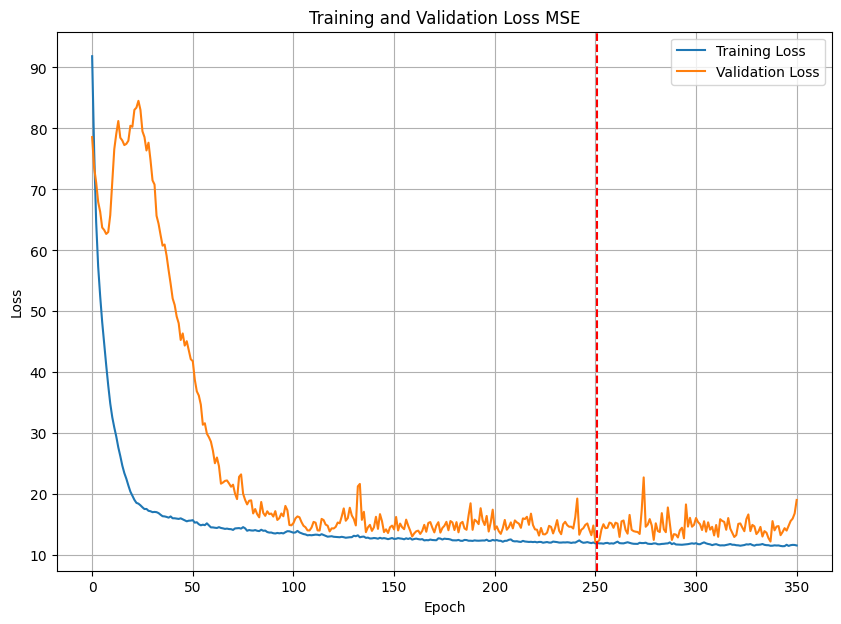

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss MSE')
plt.legend()
plt.grid(True)
plt.axvline(x=(early_stop.best_epoch + 1), color='red', linestyle='--', linewidth=1.5)

plt.savefig(path + '\\loss_curve_MSE.pdf', format='pdf', bbox_inches='tight')
plt.savefig(path + '\\loss_curve_MSE.png', dpi=600, bbox_inches='tight')

plt.show()

---

In [ ]:
#Now I will remove the 2nd generation context to compare the networks
encoding_1gen = encoding_pad[:,:,[0,1,2,3,4,5,6,7,8,18],:]
encoding_test_1gen = encoding_pad_test[:,:,[0,1,2,3,4,5,6,7,8,18],:]

In [ ]:
def build_model():
    # Initialize the Sequential model
    model = Sequential()
    
    # First convolutional layer: 
    # - Filters: 32 
    # - Kernel size: (1, 10), sliding across the second dimension of the input 
    # - Input shape: (500, 10, 2) where 500 is the number of tree leaves/nodes, 10 is the feature size, and 2 is the number of channels (leaves and nodes)
    # - Activation function: ELU (Exponential Linear Unit)
    # - Groups: 2 to apply separate convolutions for the two channels (leaves and nodes)
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 10), input_shape=(500, 10, 2), activation='elu', groups=2))
    
    # Apply batch normalization to stabilize and speed up the training process
    model.add(BatchNormalization())
    
    # Second convolutional layer: 
    # - Filters: 32
    # - Kernel size: (1, 1) to process each feature independently
    # - Activation function: ELU
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 1), activation='elu'))
    
    # Apply batch normalization again
    model.add(BatchNormalization())
    
    # Third convolutional layer: 
    # - Filters: 32
    # - Kernel size: (1, 1) for further feature processing
    # - Activation function: ELU
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 1), activation='elu'))
    
    # Apply batch normalization for the final time before flattening
    model.add(BatchNormalization())
    
    # Flatten the 2D feature maps from the convolutional layers into a 1D vector, 
    # which will be passed to the fully connected (dense) layers
    model.add(GlobalAveragePooling2D())
    
    # Fully connected (FFNN) part:
    # Dense layers with decreasing number of units, all using ELU activation:
    model.add(Dense(64, activation='elu'))   # First dense layer with 64 units
    model.add(Dense(32, activation='elu'))   # Second dense layer with 32 units
    model.add(Dense(16, activation='elu'))   # Third dense layer with 16 units
    model.add(Dense(8, activation='elu'))    # Fourth dense layer with 8 units
    
    # Output layer: 
    # - 2 output neurons, corresponding to the 2 target parameters to predict
    # - Activation function: ELU
    model.add(Dense(2, activation='elu'))
    
    # Show the summary of the model structure (number of layers, shapes of outputs, etc.)
    model.summary()

    # Return the constructed model
    return model

In [ ]:
from keras import losses

# Initialize the model using the build_model function that was previously defined
estimator = build_model()

# Compile the model:
# - Loss function: 'mean_absolute_percentage_error' (MAPE) is used to measure the error in terms of percentage for regression problems
# - Optimizer: 'Adam' is used to minimize the loss function efficiently
# - Metrics: 'mae' (mean absolute error) is used to track the model's performance during training
estimator.compile(loss=losses.mean_absolute_percentage_error, optimizer='Adam', metrics=['mae'])

# Early stopping callback to prevent overfitting:
# - monitor: monitor the validation loss during training
# - patience: stop training if the validation loss doesn't improve for 100 consecutive epochs
# - mode: 'min' indicates that training will stop when the validation loss reaches its minimum
# - restore_best_weights: restore the weights from the best epoch (the one with the lowest validation loss)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', restore_best_weights=True)

# Custom callback to display training progress:
# - Print a dot for every epoch (or newline every 100 epochs) to indicate progress in training
class PrintD(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0:  # Print a newline every 100 epochs
            print('')
        print('.', end='')  # Print a dot to indicate progress during each epoch

# Set the maximum number of epochs (iterations over the entire dataset)
EPOCHS = 1000

# Train the model using the `fit` method:
# - encoding_pad: The padded training data (inputs)
# - Y: The target values (outputs)
# - verbose: set to 1 to print progress during training
# - epochs: The number of times to iterate over the entire dataset
# - validation_split: the fraction of data to use for validation (used to monitor validation loss)
# - batch_size: the number of samples per gradient update
# - callbacks: list of callbacks to be used during training (early stopping and progress display)
history = estimator.fit(encoding_1gen, Y, verbose=1, epochs=EPOCHS, validation_split=valid_frac, batch_size=1024, callbacks=[early_stop, PrintD()])

# Save the model architecture to a JSON file:
# - The model structure (architecture) is saved as a JSON string
from keras.models import model_from_json
model = estimator.to_json()
with open('./Trained_Models/Trained_1Generation_BD.json', 'w') as json_file:
    json_file.write(model)

# Save the model weights to an H5 file:
# - The weights (learned parameters) of the trained model are saved to a file
estimator.save_weights('./Trained_Models/Trained_1Generation_BD.h5')

# Print a confirmation message when the model and weights are saved
print('model saved!')

In [ ]:
#load the model
from keras.models import model_from_json
json_file = open('./Trained_Models/Trained_1Generation_BD.json', 'r')
model = json_file.read()
json_file.close()
estimator = model_from_json(model)
#load weights
estimator.load_weights('./Trained_Models/Trained_1Generation_BD.h5')
print('model loaded!')

# predict values for the test set
predicted_test = pd.DataFrame(estimator.predict(encoding_test_1gen))
predicted_test.columns = Y_test.columns # rename correctly the columns
predicted_test.index = Y_test.index # rename indexes for correspondence

In [ ]:
####Save the target and predicted values in dataframes

#Target
Y_test_rescaled=pd.DataFrame(Y_test)
Y_test_rescaled['infectious_period'] = Y_test_rescaled['infectious_period']*param_test['resc_factor']
Y_test_rescaled.to_csv('./Predictions/BD_target.csv', header=True)

#Predicted
predicted_test['infectious_period'] = predicted_test['infectious_period']*param_test['resc_factor']
predicted_test.to_csv('./Predictions/1Generation_BD_predicted.csv', header=True)

In [ ]:
#Now I will remove all context to compare the networks
encoding_NoContext = encoding_pad[:,:,[0,1,2,3,18],:]
encoding_test_NoContext = encoding_pad_test[:,:,[0,1,2,3,18],:]

In [ ]:
def build_model():
    # Initialize the Sequential model
    model = Sequential()
    
    # First convolutional layer: 
    # - Filters: 32 
    # - Kernel size: (1, 5), sliding across the second dimension of the input 
    # - Input shape: (500, 5, 2) where 500 is the number of tree leaves/nodes, 5 is the feature size, and 2 is the number of channels (leaves and nodes)
    # - Activation function: ELU (Exponential Linear Unit)
    # - Groups: 2 to apply separate convolutions for the two channels (leaves and nodes)
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 5), input_shape=(500, 5, 2), activation='elu', groups=2))
    
    # Apply batch normalization to stabilize and speed up the training process
    model.add(BatchNormalization())
    
    # Second convolutional layer: 
    # - Filters: 32
    # - Kernel size: (1, 1) to process each feature independently
    # - Activation function: ELU
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 1), activation='elu'))
    
    # Apply batch normalization again
    model.add(BatchNormalization())
    
    # Third convolutional layer: 
    # - Filters: 32
    # - Kernel size: (1, 1) for further feature processing
    # - Activation function: ELU
    model.add(Conv2D(filters=32, use_bias=False, kernel_size=(1, 1), activation='elu'))
    
    # Apply batch normalization for the final time before flattening
    model.add(BatchNormalization())
    
    # Flatten the 2D feature maps from the convolutional layers into a 1D vector, 
    # which will be passed to the fully connected (dense) layers
    model.add(GlobalAveragePooling2D())
    
    # Fully connected (FFNN) part:
    # Dense layers with decreasing number of units, all using ELU activation:
    model.add(Dense(64, activation='elu'))   # First dense layer with 64 units
    model.add(Dense(32, activation='elu'))   # Second dense layer with 32 units
    model.add(Dense(16, activation='elu'))   # Third dense layer with 16 units
    model.add(Dense(8, activation='elu'))    # Fourth dense layer with 8 units
    
    # Output layer: 
    # - 2 output neurons, corresponding to the 2 target parameters to predict
    # - Activation function: ELU
    model.add(Dense(2, activation='elu'))
    
    # Show the summary of the model structure (number of layers, shapes of outputs, etc.)
    model.summary()

    # Return the constructed model
    return model

In [ ]:
from keras import losses

# Initialize the model using the build_model function that was previously defined
estimator = build_model()

# Compile the model:
# - Loss function: 'mean_absolute_percentage_error' (MAPE) is used to measure the error in terms of percentage for regression problems
# - Optimizer: 'Adam' is used to minimize the loss function efficiently
# - Metrics: 'mae' (mean absolute error) is used to track the model's performance during training
estimator.compile(loss=losses.mean_absolute_percentage_error, optimizer='Adam', metrics=['mae'])

# Early stopping callback to prevent overfitting:
# - monitor: monitor the validation loss during training
# - patience: stop training if the validation loss doesn't improve for 100 consecutive epochs
# - mode: 'min' indicates that training will stop when the validation loss reaches its minimum
# - restore_best_weights: restore the weights from the best epoch (the one with the lowest validation loss)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', restore_best_weights=True)

# Custom callback to display training progress:
# - Print a dot for every epoch (or newline every 100 epochs) to indicate progress in training
class PrintD(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0:  # Print a newline every 100 epochs
            print('')
        print('.', end='')  # Print a dot to indicate progress during each epoch

# Set the maximum number of epochs (iterations over the entire dataset)
EPOCHS = 1000

# Train the model using the `fit` method:
# - encoding_pad: The padded training data (inputs)
# - Y: The target values (outputs)
# - verbose: set to 1 to print progress during training
# - epochs: The number of times to iterate over the entire dataset
# - validation_split: the fraction of data to use for validation (used to monitor validation loss)
# - batch_size: the number of samples per gradient update
# - callbacks: list of callbacks to be used during training (early stopping and progress display)
history = estimator.fit(encoding_NoContext, Y, verbose=1, epochs=EPOCHS, validation_split=valid_frac, batch_size=1024, callbacks=[early_stop, PrintD()])

# Save the model architecture to a JSON file:
# - The model structure (architecture) is saved as a JSON string
from keras.models import model_from_json
model = estimator.to_json()
with open('./Trained_Models/Trained_NoContext_BD.json', 'w') as json_file:
    json_file.write(model)

# Save the model weights to an H5 file:
# - The weights (learned parameters) of the trained model are saved to a file
estimator.save_weights('./Trained_Models/Trained_NoContext_BD.h5')

# Print a confirmation message when the model and weights are saved
print('model saved!')

In [ ]:
#load the model
from keras.models import model_from_json
json_file = open('./Trained_Models/Trained_NoContext_BD.json', 'r')
model = json_file.read()
json_file.close()
estimator = model_from_json(model)
#load weights
estimator.load_weights('./Trained_Models/Trained_NoContext_BD.h5')
print('model loaded!')

# predict values for the test set
predicted_test = pd.DataFrame(estimator.predict(encoding_test_NoContext))
predicted_test.columns = Y_test.columns # rename correctly the columns
predicted_test.index = Y_test.index # rename indexes for correspondence

In [ ]:
####Save the target and predicted values in dataframes

#Target
Y_test_rescaled=pd.DataFrame(Y_test)
Y_test_rescaled['infectious_period'] = Y_test_rescaled['infectious_period']*param_test['resc_factor']
Y_test_rescaled.to_csv('./Predictions/BD_target.csv', header=True)

#Predicted
predicted_test['infectious_period'] = predicted_test['infectious_period']*param_test['resc_factor']
predicted_test.to_csv('./Predictions/NoContext_BD_predicted.csv', header=True)